In [192]:
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [193]:
from data_load import scaled_data, raw_data, result, data_info

In [194]:
scaled_data['입열량'] = scaled_data['전류'] * scaled_data['전압'] * scaled_data['통전시간']
scaled_data.head()

,Unnamed: 0,용접 가압력,전류,전압,통전시간,입열량
0,0,0.004482,0.001717,0.002506,0.000461,1.982633e-09
1,1,0.005412,0.000501,0.002506,0.000922,1.156537e-09
2,2,0.004989,0.000358,0.507830,0.000922,1.674226e-07
3,3,0.005243,0.000358,0.002506,0.000922,8.260981e-10
4,4,0.005327,0.000143,0.002506,0.000461,1.652194e-10


In [195]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [196]:
# Thickness는 모두 같은 값이므로 예측에 영향 X

print(np.sum(raw_data['Thickness 1(mm)'] != 0.7))
print(np.sum(raw_data['Thickness 2(mm)'] != 0.7))

0
0


In [197]:
scaled_data = scaled_data.drop(columns = ['Unnamed: 0'])

In [198]:
# Isolatoin tree로 이상치 발견

model = IsolationForest(contamination=0.0038, random_state=42)

model.fit(scaled_data)

predictions = model.predict(scaled_data)


In [199]:
# 이상치 군집화

idx = (predictions == -1)

X = scaled_data.loc[idx, :].copy() 

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

In [200]:
X['cluster'] = labels

X.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
94,0.005158,0.532837,0.002610,0.000922,1.281829e-06,0
1692,0.004989,0.369008,0.002610,0.000922,8.877112e-07,0
1693,0.004989,0.512448,0.002610,0.000922,1.232779e-06,0
1934,0.042280,0.003362,0.550637,0.000922,1.706430e-06,1
1943,0.043210,0.003076,0.686782,0.000922,1.947210e-06,1


In [201]:
undercut_idx = result['defect type'] == 1
lack_idx = result['defect type'] == 2
crack_idx = result['defect type'] == 3


anomaly1 = np.sum(labels == 0)
anomaly2 = np.sum(labels == 1) 
anomaly3 = np.sum(labels == 2) 
print(anomaly1, anomaly2, anomaly3)
print()

defect = pd.Series(result['defect'], dtype=int)
print(np.sum(defect[undercut_idx]),np.sum(defect[crack_idx]), np.sum(defect[lack_idx]))

26 11 9

14 12 13


In [202]:
anomaly1 = X.loc[X['cluster'] == 0, :]
anomaly2 = X.loc[X['cluster'] == 1, :]
anomaly3 = X.loc[X['cluster'] == 2, :]

In [203]:
anomaly1.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
94,0.005158,0.532837,0.002610,0.000922,1.281829e-06,0
1692,0.004989,0.369008,0.002610,0.000922,8.877112e-07,0
1693,0.004989,0.512448,0.002610,0.000922,1.232779e-06,0
1992,0.016489,0.412505,0.003132,0.000461,5.954096e-07,0
2008,0.012938,0.332451,0.002506,0.000922,7.677755e-07,0


In [204]:
anomaly2.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
1934,0.042280,0.003362,0.550637,0.000922,0.000002,1
1943,0.043210,0.003076,0.686782,0.000922,0.000002,1
1944,0.043210,0.003076,0.791188,0.000922,0.000002,1
4203,0.004735,0.001789,0.507830,0.001382,0.000001,1
4748,0.042280,0.003362,0.550637,0.000922,0.000002,1


In [205]:
anomaly3.head()

,용접 가압력,전류,전압,통전시간,입열량,cluster
2108,0.052173,0.003219,0.003132,0.945622,0.000010,2
2109,0.052258,0.003219,0.003132,0.511521,0.000005,2
4922,0.052173,0.003219,0.003132,0.945622,0.000010,2
4923,0.052258,0.003219,0.003132,0.521659,0.000005,2
8031,0.052258,0.003219,0.003132,0.484793,0.000005,2


C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 51217 (\N{HANGUL SYLLABLE JEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 50517 (\N{HANGUL SYLLABLE AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82105\AppData\Local\Temp\ipykernel_14876\2879493542.py:39: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing 

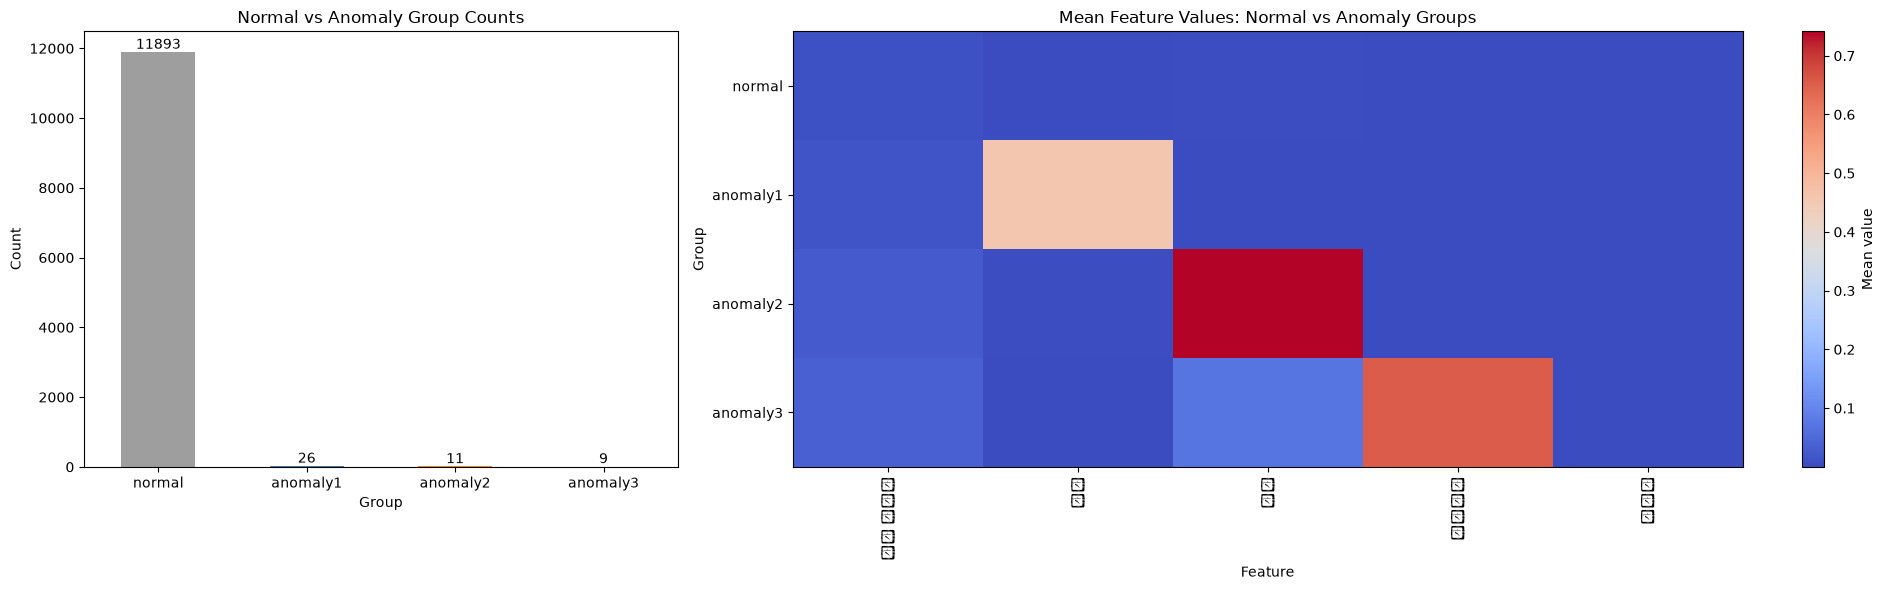

,normal,anomaly1,anomaly2,anomaly3
용접 가압력,0.011,0.015,0.029,0.036
전류,0.002,0.455,0.003,0.003
전압,0.003,0.003,0.742,0.071
통전시간,0.003,0.001,0.001,0.654
입열량,0.000,0.000,0.000,0.000


In [206]:
# Isolation Forest에서 정상으로 판정된 데이터
normal_data = scaled_data.loc[predictions == 1, :]

comparison_groups = {
    'normal': normal_data,
    'anomaly1': anomaly1,
    'anomaly2': anomaly2,
    'anomaly3': anomaly3,
}

# 정상 데이터와 anomaly 그룹별 데이터 개수 비교
counts = pd.Series({name: len(group) for name, group in comparison_groups.items()})

fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 2]})

counts.plot(kind='bar', ax=axes[0], color=['#9E9E9E', '#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Normal vs Anomaly Group Counts')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for index, value in enumerate(counts):
    axes[0].text(index, value, str(value), ha='center', va='bottom')

# 정상 데이터와 anomaly 그룹의 변수별 평균값 비교
mean_values = pd.DataFrame({name: group.drop(columns='cluster', errors='ignore').mean()
                            for name, group in comparison_groups.items()})
mean_values = mean_values.select_dtypes(include='number')

image = axes[1].imshow(mean_values.T, aspect='auto', cmap='coolwarm')
axes[1].set_title('Mean Feature Values: Normal vs Anomaly Groups')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Group')
axes[1].set_xticks(range(len(mean_values.index)))
axes[1].set_xticklabels(mean_values.index, rotation=90)
axes[1].set_yticks(range(len(mean_values.columns)))
axes[1].set_yticklabels(mean_values.columns)
fig.colorbar(image, ax=axes[1], label='Mean value')

plt.tight_layout()
plt.show()

mean_values.round(3)
